# Drift estimation using phase cross correlation.

Phase cross correlation is used for drift estimation.
However, the methodology can be erroneous in the presence of noise or bad image quality.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gnganesh99/Misc/blob/main/drift_correction_pcc.ipynb)

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import numpy as np

In [4]:
from skimage import data
from skimage.registration import phase_cross_correlation
from skimage.registration._phase_cross_correlation import _upsampled_dft
from scipy.ndimage import fourier_shift
from skimage import transform

Visualize data

In [5]:
#! wget https://www.dropbox.com/scl/fo/4gn6hvnopuqrmii40tbqi/AMlNZwutis5gpJ9K3xg4wpc?rlkey=27s1mcvg68gl661f6lf6lpznp&st=6uxq1rn0&dl=0



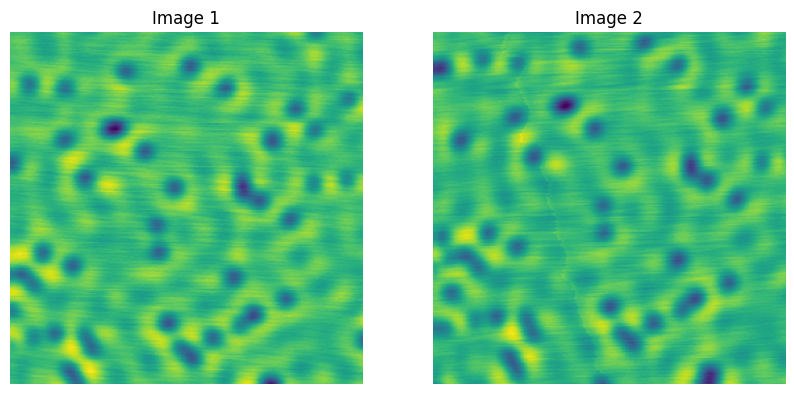

In [8]:
im1 = Image.open(r"data_drift_correction/original/images_with_drift/CO_on_Cu_0196.jpg")
im2 = Image.open(r"data_drift_correction/original/images_with_drift/CO_on_Cu_0199.jpg")

fig,ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(im1)

ax[0].set_axis_off()
ax[0].set_title("Image 1")


ax[1].imshow(im2)
ax[1].set_axis_off()
ax[1].set_title("Image 2")
plt.show()


Compute shift on single channel numpy arrays.

In [ ]:
# Convert images to grayscale numpy arrays

img1 = np.array(im1.convert("L"))
img2 = np.array(im2.convert("L"))


# Compute shift using phase cross-correlation
shift, error, diffphase = phase_cross_correlation(img1, img2, upsample_factor=10)

# shift is returned as [row_shift, col_shift] which is [y, x]
shift_y, shift_x = shift

print(f"Drift detected: X = {shift_x:.2f} pixels, Y = {shift_y:.2f} pixels")


Drift detected: X = 0.10 pixels, Y = 130.20 pixels


In [ ]:
def get_corrected_image(image, shift):

    """ Apply subpixel shift to an image using Fourier shift theorem."""

    offset_image_f = fourier_shift(np.fft.fftn(image), shift)
    offset_image = np.fft.ifftn(offset_image_f)
    offset_image = abs(offset_image)

    return offset_image


Corrected image

The shifted image is not perfect, however provides a mesure of the drift direction.

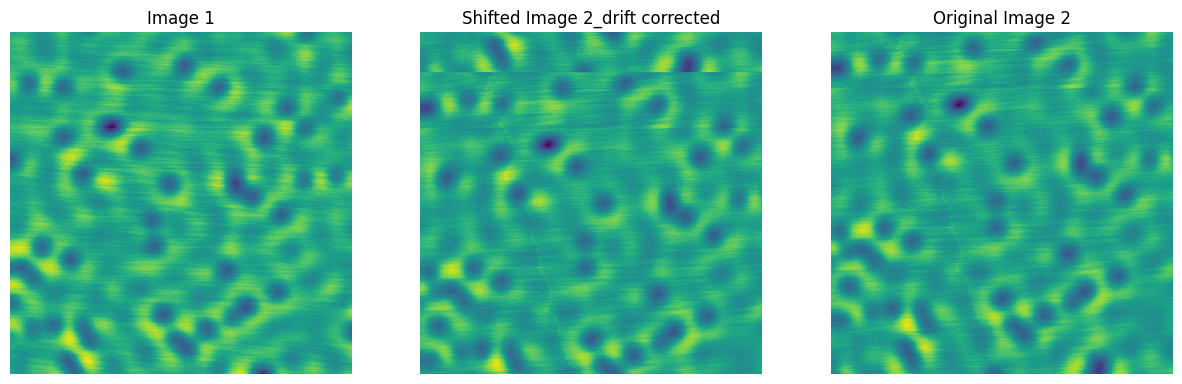

In [ ]:
# shift = np.array([100, 100])

img2_shifted = get_corrected_image(img2, shift)



fig,ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(img1)
ax[0].axis('off')
ax[0].set_title("Image 1")

ax[1].imshow(img2_shifted)
ax[1].axis('off')
ax[1].set_title("Shifted Image 2_drift corrected")

ax[2].imshow(img2)
ax[2].axis('off')   
ax[2].set_title("Original Image 2")
plt.show()
